In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import glob

#################
# Loading Dataset
#################
path = '/content/drive/MyDrive/CICIoV2024/*.csv'
files = glob.glob(path)

# Merging csvs
dfs = []
for f in files:
    dfs.append(pd.read_csv(f))

df = pd.concat(dfs, ignore_index=True)
print(df.shape)

(1408219, 12)


In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

####################
# Data Preprocessing
####################
# Dropping nan and inf values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Dropping unnecessary columns
X = df.drop(columns=['ID', 'label', 'category', 'specific_class'])
feature_names = X.columns.tolist()

# Standard Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Binary Class Label Encoder
le_binary = LabelEncoder()
y_binary = le_binary.fit_transform(df['label'])

# Multi Class Label Encoder
le_multi = LabelEncoder()
y_multi = le_multi.fit_transform(df['specific_class'])

print("Classes (binary):", le_binary.classes_)
print("Classes (multiclass):", le_multi.classes_)
print("X shape:", X_scaled.shape)

Classes (binary): ['ATTACK' 'BENIGN']
Classes (multiclass): ['BENIGN' 'DoS' 'GAS' 'RPM' 'SPEED' 'STEERING_WHEEL']
X shape: (1408219, 8)


In [6]:
##################
# Train test split
##################
# 70% training 30% testing
X_train, X_test, y_train_b, y_test_b = train_test_split(
    X_scaled, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_scaled, y_multi, test_size=0.3, random_state=42, stratify=y_multi
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (985753, 8)
Test size: (422466, 8)


In [7]:

# Reshape for CNN
X_train_r = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_r = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

X_train_mr = X_train_m.reshape(X_train_m.shape[0], X_train_m.shape[1], 1)
X_test_mr = X_test_m.reshape(X_test_m.shape[0], X_test_m.shape[1], 1)

print("Reshaped train:", X_train_r.shape)

Reshaped train: (985753, 8, 1)


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

#####################
# Build CNN GRU Model
#####################
def build_cnn_gru(output_units, activation):
    inp = layers.Input(shape=(8, 1))
    x = layers.Conv1D(32, kernel_size=2, activation='relu')(inp)
    x = layers.GRU(32, return_sequences=True)(x)
    x = layers.GRU(16)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(30, activation='relu')(x)
    out = layers.Dense(output_units, activation=activation)(x)
    return models.Model(inp, out)

# Binary Model
model_binary = build_cnn_gru(1, 'sigmoid')
model_binary.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_binary.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 7, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 7, 32)          │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,373 (36.61 KB)

 Trainable params: 9,373 (36.61 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

#######################
# Training Binary Model
#######################
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_binary = model_binary.fit(
    X_train_r, y_train_b,
    validation_data=(X_test_r, y_test_b),
    epochs=20,
    batch_size=256,
    callbacks=[es]
)

Epoch 1/20
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.9875 - loss: 0.0371 - val_accuracy: 0.9999 - val_loss: 9.9614e-04
Epoch 2/20
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - accuracy: 0.9992 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 2.2047e-04
Epoch 3/20
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9995 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 2.4692e-04
Epoch 4/20
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - accuracy: 0.9994 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 1.0692e-04
Epoch 5/20
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 41s 11ms/step - accuracy: 0.9986 - loss: 0.0069 - val_accuracy: 1.0000 - val_loss: 8.5556e-05
Epoch 6/20
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - accuracy: 0.9996 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 8.4437e-05
Epoch 7/20
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - accuracy: 0.9999 - loss: 8.0568e-04 - val_accuracy: 1.0000 - val_loss: 7.5429e-05
Epoch 8/20
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 37s 

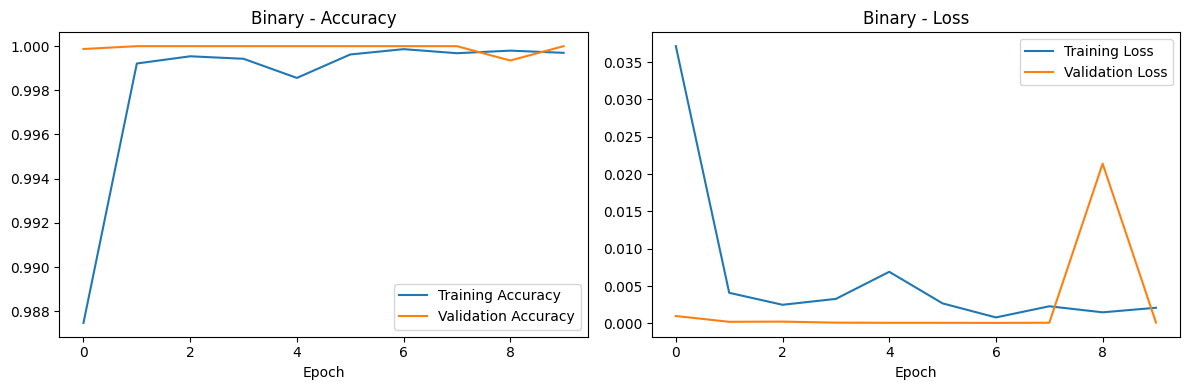

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

##########################
# Plotting Training curves
##########################
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_binary.history['accuracy'], label='Training Accuracy')
ax1.plot(history_binary.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Binary - Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history_binary.history['loss'], label='Training Loss')
ax2.plot(history_binary.history['val_loss'], label='Validation Loss')
ax2.set_title('Binary - Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('binary_training_curves.png', dpi=150)
plt.show()

13203/13203 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00     55345
      BENIGN       1.00      1.00      1.00    367121

    accuracy                           1.00    422466
   macro avg       1.00      1.00      1.00    422466
weighted avg       1.00      1.00      1.00    422466



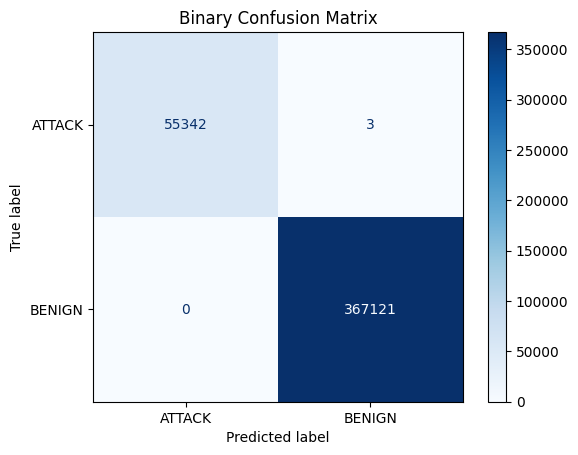

ROC AUC: 1.0000


In [11]:
############################################
# Classification Report and Confusion Matrix
############################################

# Predictions
y_pred_b = (model_binary.predict(X_test_r) > 0.5).astype(int).flatten()

# Classification report
print(classification_report(y_test_b, y_pred_b, target_names=le_binary.classes_))

# Confusion matrix
cm = confusion_matrix(y_test_b, y_pred_b)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_binary.classes_)
disp.plot(cmap='Blues')
plt.title('Binary Confusion Matrix')
plt.savefig('binary_confusion_matrix.png', dpi=150)
plt.show()

# ROC AUC
auc = roc_auc_score(y_test_b, y_pred_b)
print(f"ROC AUC: {auc:.4f}")

In [12]:
###########################
# Training MultiClass Model
###########################
model_multi = build_cnn_gru(6, 'softmax')
model_multi.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_multi = model_multi.fit(
    X_train_mr, y_train_m,
    validation_data=(X_test_mr, y_test_m),
    epochs=20,
    batch_size=256,
    callbacks=[es]
)

Epoch 1/20
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - accuracy: 0.9800 - loss: 0.0682 - val_accuracy: 0.9964 - val_loss: 0.0052
Epoch 2/20
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - accuracy: 0.9963 - loss: 0.0064 - val_accuracy: 0.9964 - val_loss: 0.0054
Epoch 3/20
3851/3851 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - accuracy: 0.9961 - loss: 0.0079 - val_accuracy: 0.9964 - val_loss: 0.0051


13203/13203 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step
                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00    367122
           DoS       1.00      1.00      1.00     22399
           GAS       1.00      1.00      1.00      2997
           RPM       1.00      0.91      0.95     16470
         SPEED       0.83      1.00      0.91      7485
STEERING_WHEEL       1.00      1.00      1.00      5993

      accuracy                           1.00    422466
     macro avg       0.97      0.98      0.98    422466
  weighted avg       1.00      1.00      1.00    422466



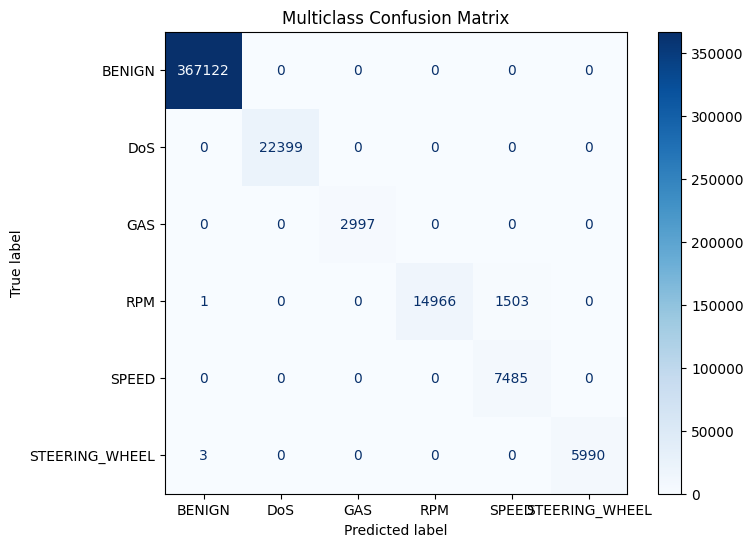

In [13]:
#############################
# Evaluating MultiClass Model
#############################
y_pred_m = np.argmax(model_multi.predict(X_test_mr), axis=1)

print(classification_report(y_test_m, y_pred_m, target_names=le_multi.classes_))

cm_m = confusion_matrix(y_test_m, y_pred_m)
disp_m = ConfusionMatrixDisplay(confusion_matrix=cm_m, display_labels=le_multi.classes_)
fig, ax = plt.subplots(figsize=(8,6))
disp_m.plot(cmap='Blues', ax=ax)
plt.title('Multiclass Confusion Matrix')
plt.savefig('multiclass_confusion_matrix.png', dpi=150)
plt.show()

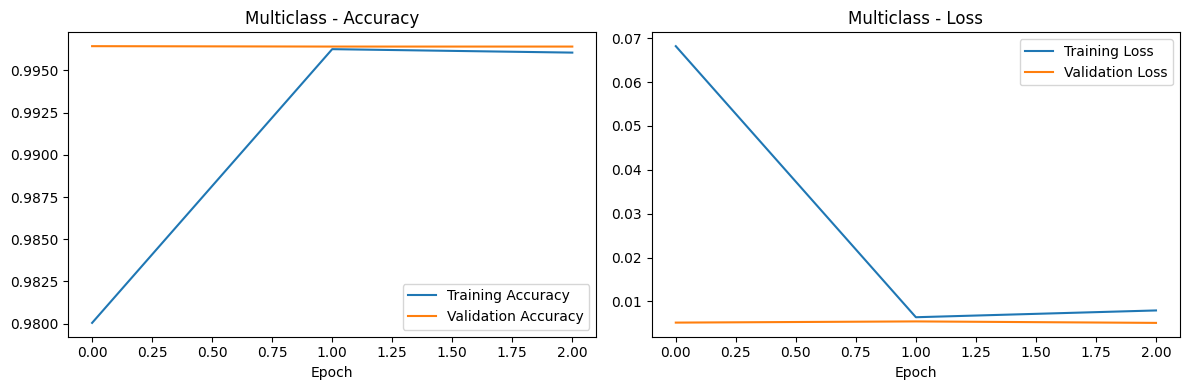

In [14]:
#####################################
# Plotting MultiClass Training Curves
#####################################
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_multi.history['accuracy'], label='Training Accuracy')
ax1.plot(history_multi.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Multiclass - Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history_multi.history['loss'], label='Training Loss')
ax2.plot(history_multi.history['val_loss'], label='Validation Loss')
ax2.set_title('Multiclass - Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('multiclass_training_curves.png', dpi=150)
plt.show()

In [15]:
!pip install shap -q
import shap

####################
# SHAP Configuration
####################

background_flat = X_train[:200]
test_flat = X_test[:200]

# Wrap model to accept 2D input by reshaping internally
def model_predict(x):
    x_reshaped = x.reshape(x.shape[0], x.shape[1], 1)
    return model_binary.predict(x_reshaped, verbose=0)

# Kernel Explainer Used
explainer = shap.KernelExplainer(model_predict, background_flat)
shap_values = explainer.shap_values(test_flat, nsamples=100)

  0%|          | 0/200 [00:00<?, ?it/s]

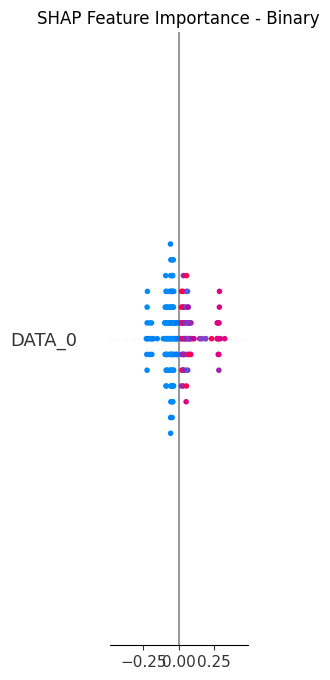

In [16]:
###################
# SHAP Summary Plot
###################
shap.summary_plot(shap_values, test_flat,feature_names=feature_names,plot_type='bar',show=False)

plt.title('SHAP Feature Importance - Binary')
plt.savefig('shap_binary_summary.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3893/3945067222.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  base_values=float(explainer.expected_value),


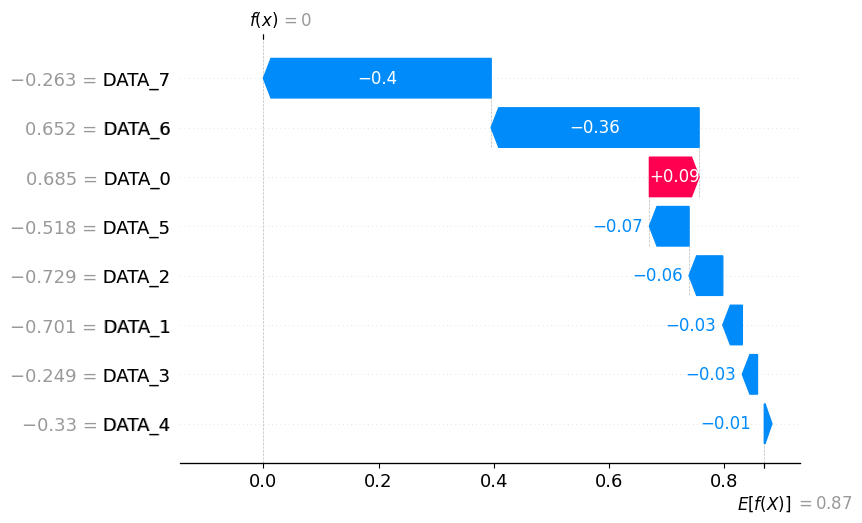

<Figure size 640x480 with 0 Axes>

In [17]:
################
# Waterfall Plot
################
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0].flatten(),
        base_values=float(explainer.expected_value),
        data=test_flat[0],
        feature_names=feature_names
    )
)
plt.savefig('shap_waterfall_binary.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
import shutil

###########################
# Saving all plots to drive
###########################
shutil.copy('binary_training_curves.png', '/content/drive/MyDrive/CICIoV2024/')
shutil.copy('binary_confusion_matrix.png', '/content/drive/MyDrive/CICIoV2024/')
shutil.copy('multiclass_confusion_matrix.png', '/content/drive/MyDrive/CICIoV2024/')
shutil.copy('multiclass_training_curves.png', '/content/drive/MyDrive/CICIoV2024/')
shutil.copy('shap_binary_summary.png', '/content/drive/MyDrive/CICIoV2024/')
shutil.copy('shap_waterfall_binary.png', '/content/drive/MyDrive/CICIoV2024/')

'/content/drive/MyDrive/CICIoV2024/shap_waterfall_binary.png'

In [19]:
import json

logs = {
    "binary": {
        "accuracy": history_binary.history['accuracy'],
        "val_accuracy": history_binary.history['val_accuracy'],
        "loss": history_binary.history['loss'],
        "val_loss": history_binary.history['val_loss']
    },
    "multiclass": {
        "accuracy": history_multi.history['accuracy'],
        "val_accuracy": history_multi.history['val_accuracy'],
        "loss": history_multi.history['loss'],
        "val_loss": history_multi.history['val_loss']
    }
}

with open('/content/drive/MyDrive/CICIoV2024/experiment_logs.json', 'w') as f:
    json.dump(logs, f, indent=2)

print("Logs saved.")

Logs saved.
